# `DiscreteControlLoopSimulator` demo

This notebook demonstrates `dynestyx.control.discrete_controller_simulators.DiscreteControlLoopSimulator`, which implements the discrete time online control loop

$$
\begin{aligned}
&x_0 \sim p(x_0)\\
&y_0 | x_0 \sim p(y_0 | x_0, t_0) \\
&\hat{x}_{0|0} = \text{FilterUpdate}(y_0, t_0) \\
&u_k, s_{k+1} = \text{ControlPolicy}(x_hat_{k|k}, s_k) \\
&x_{k+1} | x_k, u_k \sim p(x_{k+1} | x_k, u_k, t_k, t_{k+1}) \\
&y_{k+1} | x_{k+1}, u_k \sim p(y_{k+1} | x_{k+1}, u_k, t_{k+1}) \\
&\hat{x}_{k+1|k+1} = \text{FilterUpdate}(x_hat_{k|k}, u_k, y_{k+1}, t_k, t_{k+1}) \\
\end{aligned}
$$

at each step, sampling the next state and observation, filtering the observation into an updated belief, and asking the policy for the next control.

We use:
1. a simple 1D linear-Gaussian dynamical system (a noisy random walk, `x_{k+1} = A x_k + B u_k + noise`) with the full state directly observed under Gaussian noise,
2. a linear feedback policy `u_k = -K x_hat_k` that drives the state toward 0,
3. a plot comparing the controlled trajectory against an uncontrolled (`K=0`) baseline.

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro.distributions as dist

from dynestyx.control.discrete_controller_simulators import DiscreteControlLoopSimulator, filter_state_mean
from dynestyx.inference.configs.filter import KFConfig
from dynestyx.models import DynamicalModel
from dynestyx.models.observations import LinearGaussianObservation
from dynestyx.models.state_evolution import LinearGaussianStateEvolution

## 1 Simple linear dynamics

`state_dim = control_dim = observation_dim = 1`. The transition is 
$$
x_{k+1} = ax_k + u_k + \eta_k,
$$
with $a=1.05$, is linear with additive Gaussian noise. Without control, this system is unstable and $x_k \rightarrow \infty$.
The observation model is 
$$
y_k = x_k + \sigma\varepsilon_k
$$
$\sigma=0.2$, observes the full state under additive Gaussian noise. We define the dynamics in the usual dynestyx way.

In [2]:
state_dim = control_dim = obs_dim = 1

dynamics = DynamicalModel(
    initial_condition=dist.MultivariateNormal(jnp.array([5.0]), 0.1 * jnp.eye(state_dim)),
    state_evolution=LinearGaussianStateEvolution(
        A=jnp.array([[1.05]]), B=jnp.array([[1.0]]), cov=0.05 * jnp.eye(state_dim)
    ),
    observation_model=LinearGaussianObservation(
        H=jnp.eye(obs_dim, state_dim), R=0.2 * jnp.eye(obs_dim)
    ),
    control_dim=control_dim,
)

## 2. Define the controller

A simple linear feedback policy `u = -K x_hat`, implemented as an `equinox.Module` (per the control-loop's requirement that the policy be any callable, e.g. a learned neural policy or, as here, a fixed gain). `filter_state_mean` extracts a point estimate from whatever filter-family belief `DiscreteControlLoopSimulator` produces (Kalman-family states expose `.mean` directly; particle-filter states are summarized as a weighted mean instead), so the same policy code works regardless of `filter_config`.

With `a - b*k = 1 - 0.5 = 0.5`, well inside the unit circle, the closed loop should converge to 0.

In [3]:
class LinearPolicy(eqx.Module):
    K: jnp.ndarray

    def __call__(self, x_hat, s, key):
        return -self.K @ filter_state_mean(x_hat), s

## 3. Run the closed loop, with and without control

`DiscreteControlLoopSimulator` is called directly: `sim.simulate(dynamics, rng_key=key, predict_times=...)` returns a `ControlledSimulatedResult`. We use `predict_times` (not `obs_times`/`ctrl_times`) since the trajectory doesn't exist yet until the loop generates it. 

`filter_config=KFConfig(record_filtered_states_mean=True)` makes the filtered state estimate available as an output (it's needed internally either way, for the policy; this only controls whether it's also returned). We run twice with the same key: once with the stabilizing gain `K=0.5`, once with `K=0` (no control) as a baseline.

In [4]:
predict_times = jnp.arange(0.0, 30.0)


def run(K: float, key):
    policy = LinearPolicy(K=jnp.array([[K]]))
    sim = DiscreteControlLoopSimulator(
        control_policy=policy,
        policy_state_init=None,
        filter_config=KFConfig(record_filtered_states_mean=True),
    )
    return sim.simulate(dynamics, rng_key=key, predict_times=predict_times)


key = jr.PRNGKey(0)
result_controlled = run(K=0.5, key=key)
result_uncontrolled = run(K=0.0, key=key)



## 4. Plot the resulting dynamics

Top panel: noisy observations (dots) and the filtered state estimate (line) for both runs. Since the full state is directly observed here, the observations already closely track the true state, and the filtered estimate smooths out the sensor noise. Bottom panel: the control sequence chosen online by the policy for the controlled run.

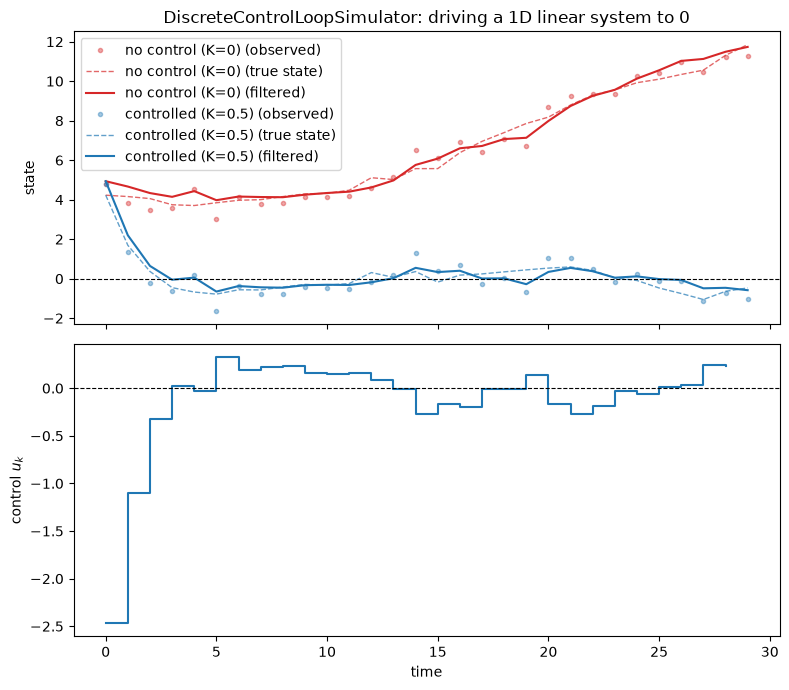

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

runs = [
    (result_uncontrolled, "no control (K=0)", "tab:red"),
    (result_controlled, "controlled (K=0.5)", "tab:blue"),
]
for result, label, color in runs:
    t = result.times[0]
    true_state = result.states[0, :, 0]
    obs = result.observations[0, :, 0]
    filtered_mean = result.filtered_states_mean[0, :, 0]
    axes[0].plot(t, obs, ".", color=color, alpha=0.4, label=f"{label} (observed)")
    axes[0].plot(t, true_state, "--", color=color, alpha=0.7, linewidth=1, label=f"{label} (true state)")
    axes[0].plot(t, filtered_mean, "-", color=color, label=f"{label} (filtered)")

axes[0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("state")
axes[0].legend()
axes[0].set_title("DiscreteControlLoopSimulator: driving a 1D linear system to 0")

t_u = result_controlled.times[0][:-1]
u = result_controlled.controls[0, :, 0]
axes[1].step(t_u, u, where="post", color="tab:blue")
axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("control $u_k$")
axes[1].set_xlabel("time")

plt.tight_layout()
plt.show()

## 5. A black-box, partially-observed nonlinear SDE

So far the dynamics were already discrete-time. Here we go further: the control loop's
transition $p(x_{k+1} \mid x_k, u_k, t_k, t_{k+1})$ is allowed to be *any* black-box callable, so
we integrate a genuine SDE with many small sub-steps between observations, and
`DiscreteControlLoopSimulator` never sees anything but the discrete grid.

We consider a 2-d dynamical system $x_t \in \mathbb{R}^2$ obeying

$$
\begin{aligned}
dx_t &= A x_t^2 + u_t + \sigma\, dW_t \\
y_{t_k} &= H x_{t_k} + \eta_{t_k}
\end{aligned}
$$

with $A = \begin{pmatrix} 0.025 & 0.01 \\ 0.01 & 0.025 \end{pmatrix}$ (mild coupling, so that
observing $x_1$ is actually informative about $x_2$) and $H = \begin{pmatrix} 1 & 0
\end{pmatrix}$ for $t_k = k \Delta t$ -- we only ever observe the first component.

Two consequences of these changes:

- **The transition has no closed form and isn't Gaussian.** A composition of many small nonlinear
  Euler-Maruyama steps is not Gaussian, so `KFConfig`/`EKFConfig` (which need a linearizable
  one-step Gaussian transition) don't apply. We use a **particle filter** (`PFConfig`)
  instead, and check below that an **ensemble Kalman filter** (`EnKFConfig`) works too.
- **$x_2$ is only observed indirectly**, through its dynamical coupling to $x_1$ via $A$'s
  off-diagonal terms.

In [60]:
from dynestyx.inference.configs.filter import EnKFConfig, PFConfig
from dynestyx.models import ContinuousTimeStateEvolution, FullDiffusion

state_dim_2d = control_dim_2d = 2
obs_dim_2d = 1
A = jnp.array([[0.025, 0.01], [0.01, 0.025]])
sigma_2d = 0.1

continuous_nonlinear_dynamics = DynamicalModel(
    initial_condition=dist.MultivariateNormal(
        jnp.array([3.0, 2.0]), 0.05 * jnp.eye(state_dim_2d)
    ),
    state_evolution=ContinuousTimeStateEvolution(
        drift=lambda x, u, t: A @ (x**2) + u,
        diffusion=FullDiffusion(sigma_2d * jnp.eye(state_dim_2d)),
    ),
    observation_model=LinearGaussianObservation(
        H=jnp.eye(obs_dim_2d, state_dim_2d), R=0.05 * jnp.eye(obs_dim_2d)
    ),
    control_dim=control_dim_2d,
)

Wrapping its output in a small `.sample(key)` / `.shape()` object turns it into a discrete-time
`state_evolution` the control loop can call without knowing anything happens in between. This is a genuine black box, only usable with filters
(PF, EnKF) that only need to *sample* the transition. The control is held constant
(zero-order hold) across the sub-steps via `control_path_eval`.

In [61]:
from dynestyx.solvers import euler_maruyama_integrate_state_to_time

substep_dt = 0.02  # ~5 EM sub-steps per 0.1-spaced observation interval


class SubSteppedSDEStep:
    """A single control-loop transition that is itself a sub-stepped SDE
    integration -- the simulator only ever sees `.sample()`/`.shape()`,
    exactly as it would for e.g. a MuJoCo step."""

    def __init__(self, cte, x_prev, u, t_now, t_next, *, dt0):
        self._cte, self._x_prev, self._u = cte, x_prev, u
        self._t_now, self._t_next, self._dt0 = t_now, t_next, dt0

    def sample(self, key):
        x_out, _, _ = euler_maruyama_integrate_state_to_time(
            self._cte,
            self._x_prev,
            self._t_now,
            key,
            self._t_next,
            dt0=self._dt0,
            control_path_eval=lambda t: self._u,
        )
        return x_out

    def shape(self):
        return self._x_prev.shape


def black_box_sde_transition(x, u, t_now, t_next):
    return SubSteppedSDEStep(
        continuous_nonlinear_dynamics.state_evolution, x, u, t_now, t_next, dt0=substep_dt
    )


nonlinear_dynamics = DynamicalModel(
    initial_condition=continuous_nonlinear_dynamics.initial_condition,
    state_evolution=black_box_sde_transition,
    observation_model=continuous_nonlinear_dynamics.observation_model,
    control_dim=continuous_nonlinear_dynamics.control_dim,
)

The controller is the same `LinearPolicy` as before, with a $2\times2$ gain $K = k \cdot I$. The case 
$k=0$ reproduces the uncontrolled (unstable) system. 

In [62]:
predict_times_2d = jnp.arange(0.0, 6.0, 0.1)


def run_2d(k: float, key, filter_config):
    policy = LinearPolicy(K=k * jnp.eye(control_dim_2d))
    sim = DiscreteControlLoopSimulator(
        control_policy=policy,
        policy_state_init=None,
        filter_config=filter_config,
    )
    return sim.simulate(nonlinear_dynamics, rng_key=key, predict_times=predict_times_2d)


pf_config = PFConfig(n_particles=500, record_filtered_states_mean=True)

key_2d = jr.PRNGKey(0)
result_pf_controlled = run_2d(k=1.0, key=key_2d, filter_config=pf_config)
result_pf_uncontrolled = run_2d(k=0.0, key=key_2d, filter_config=pf_config)

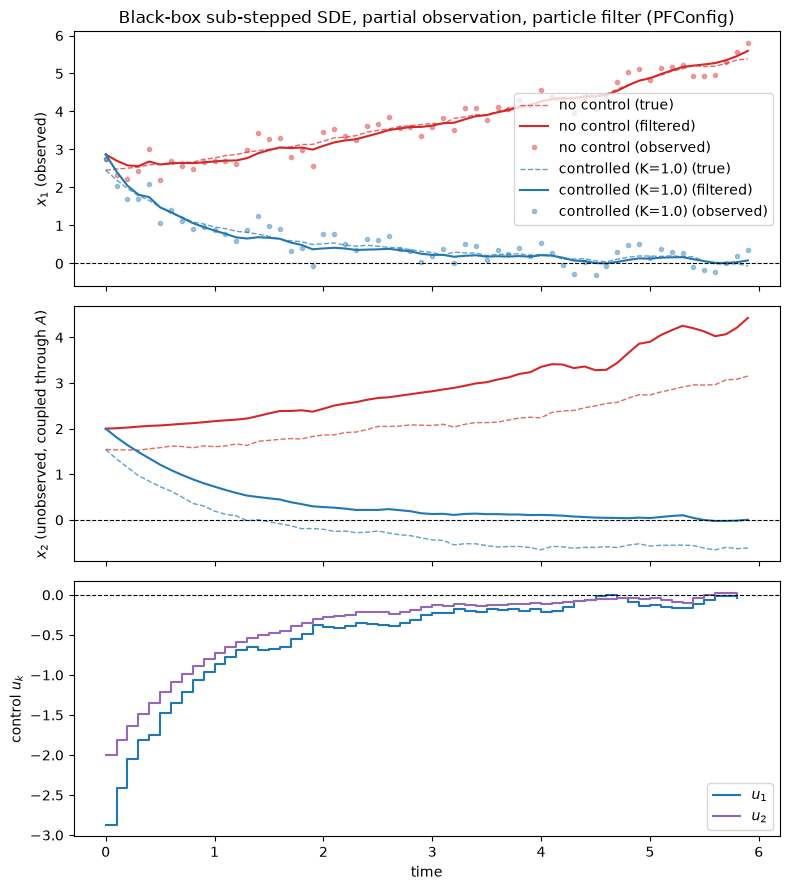

In [63]:
def plot_2d_runs(runs, controlled_result, title):
    fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

    for result, label, color in runs:
        t = result.times[0]
        true_state = result.states[0]
        filtered_mean = result.filtered_states_mean[0]
        axes[0].plot(t, true_state[:, 0], "--", color=color, alpha=0.7, linewidth=1, label=f"{label} (true)")
        axes[0].plot(t, filtered_mean[:, 0], "-", color=color, label=f"{label} (filtered)")
        axes[0].plot(t, result.observations[0][:, 0], ".", color=color, alpha=0.4, label=f"{label} (observed)")
        axes[1].plot(t, true_state[:, 1], "--", color=color, alpha=0.7, linewidth=1)
        axes[1].plot(t, filtered_mean[:, 1], "-", color=color)

    axes[0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
    axes[0].set_ylabel("$x_1$ (observed)")
    axes[0].legend()
    axes[0].set_title(title)

    axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_ylabel("$x_2$ (unobserved, coupled through $A$)")

    t_u = controlled_result.times[0][:-1]
    u = controlled_result.controls[0]
    axes[2].step(t_u, u[:, 0], where="post", color="tab:blue", label="$u_1$")
    axes[2].step(t_u, u[:, 1], where="post", color="tab:purple", label="$u_2$")
    axes[2].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
    axes[2].set_ylabel("control $u_k$")
    axes[2].set_xlabel("time")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


plot_2d_runs(
    [
        (result_pf_uncontrolled, "no control", "tab:red"),
        (result_pf_controlled, "controlled (K=1.0)", "tab:blue"),
    ],
    result_pf_controlled,
    "Black-box sub-stepped SDE, partial observation, particle filter (PFConfig)",
)

### Does an EnKF work here too?

Both `_cuthbert_filter_pf` and `_cuthbert_filter_enkf` only call
`dynamics.state_evolution(...).sample(key)` to propagate particles/ensemble members -- neither
needs `.log_prob()` or `.mean` on the transition, so both are equally black-box-compatible with
`nonlinear_dynamics` above (KF/EKF, which linearize a Gaussian one-step transition, are not --
there's no such transition here to linearize). EnKF's only extra requirement is on the
*observation* model: state-independent Gaussian noise. Since `nonlinear_dynamics.observation_model`
is still a `LinearGaussianObservation` (just with a rectangular $H$), EnKF takes its fast
closed-form path -- no probing, no rejection.

So yes: `EnKFConfig` runs on the identical setup below. The difference is accuracy, not
compatibility -- EnKF represents the filtering distribution as a Gaussian ensemble (cheap, and
fine here since the nonlinearity is mild and the noise is Gaussian), while PF makes no
distributional assumption on the belief at all, which matters more the further the true
posterior drifts from Gaussian (stronger nonlinearity, multimodal beliefs, etc). For this
system the two should look similar; PF remains the more general default for a genuinely
arbitrary black box.

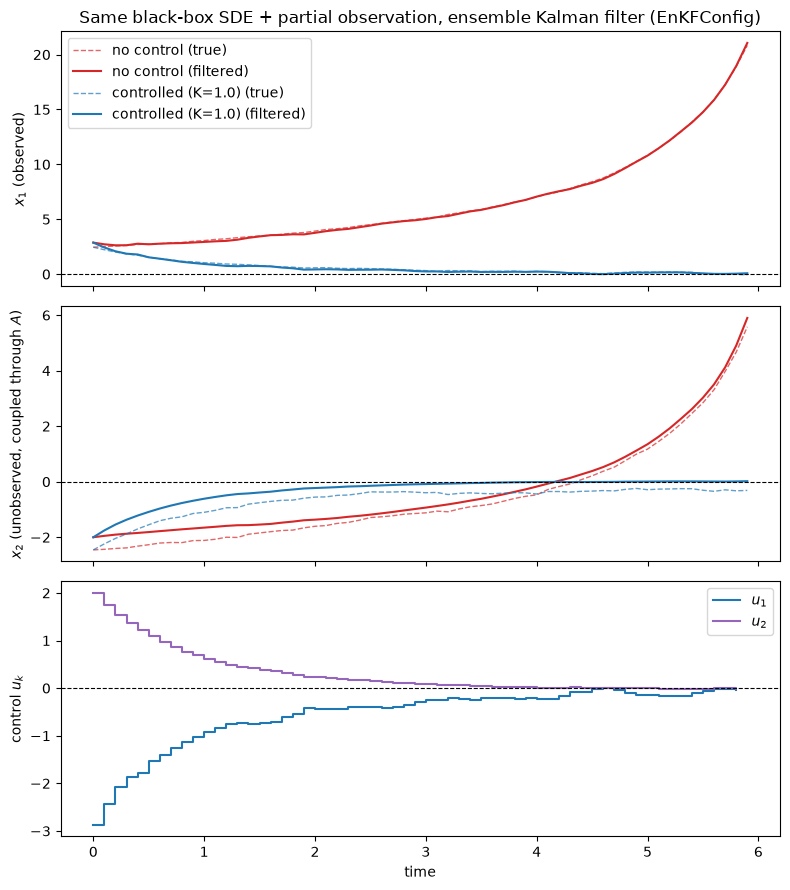

In [10]:
enkf_config = EnKFConfig(n_particles=500, record_filtered_states_mean=True)

result_enkf_controlled = run_2d(k=1.0, key=key_2d, filter_config=enkf_config)
result_enkf_uncontrolled = run_2d(k=0.0, key=key_2d, filter_config=enkf_config)

plot_2d_runs(
    [
        (result_enkf_uncontrolled, "no control", "tab:red"),
        (result_enkf_controlled, "controlled (K=1.0)", "tab:blue"),
    ],
    result_enkf_controlled,
    "Same black-box SDE + partial observation, ensemble Kalman filter (EnKFConfig)",
)

## 6. A sampling-based alternative: MPPI

All the policies so far have been deterministic linear feedback (`u = -K x_hat`). `dynestyx.control.MPPI` is a different kind of policy entirely -- Model Predictive Path Integral control: at every step, sample many candidate control sequences, roll each one forward, score them with a cost function, and take the softmax-weighted average as the actual control (only the first step of that average is applied; the rest becomes next step's warm-started plan). It plugs into the exact same `control_policy=` slot as `LinearPolicy` above -- `DiscreteControlLoopSimulator` doesn't know or care which kind of policy it's driving.

MPPI needs two things `DynamicalModel` doesn't directly provide: a **rollout function** `(x0, u_seq) -> x_seq` for *planning* (deliberately generic -- it doesn't have to use `dynamics.state_evolution` at all; it could wrap an external simulator), and a **loss function** scoring a rolled-out trajectory. Here we build the rollout directly from `dynamics.state_evolution`'s deterministic mean -- a standard MPPI simplification: the real system is stochastic (see the control loop's own `.sample()` calls), but the *planner* only needs a reasonable prediction of where a candidate control sequence leads, not a faithful stochastic simulation.

In [11]:
from dynestyx.control import MPPI, mppi_initial_state


def make_mppi_rollout(dynamics, dt=1.0):
    def rollout_one(x0, u_seq):
        def step(x, u):
            x_next = dynamics.state_evolution(x, u, 0.0, dt).mean
            return x_next, x_next

        _, xs = jax.lax.scan(step, x0, u_seq)
        return xs

    return jax.vmap(rollout_one, in_axes=(None, 0))


def quadratic_loss(x_seq, u_seq):
    return jnp.sum(x_seq**2) + 0.01 * jnp.sum(u_seq**2)

`horizon` and `n_samples` trade off planning quality against compute; `noise_std` controls how widely candidate sequences are spread around the current plan, and `temperature` controls how sharply the softmax weighting favors low-cost samples. These values are not tuned beyond "converges reliably" -- the point here is the mechanism, not competitive performance. `dynamics`, `control_dim`, and `predict_times` are the same ones defined in section 1, and `trace_uncontrolled` (the `K=0` baseline) is reused directly from section 3 for comparison.

In [12]:
horizon = 10
n_samples = 300

mppi = MPPI(
    dynamics_model=make_mppi_rollout(dynamics),
    loss_fn=quadratic_loss,
    horizon=horizon,
    n_samples=n_samples,
    noise_std=1.0,
    temperature=1.0,
)

sim_mppi = DiscreteControlLoopSimulator(
    control_policy=mppi,
    policy_state_init=mppi_initial_state(horizon, control_dim),
    filter_config=KFConfig(record_filtered_states_mean=True),
)

result_mppi = sim_mppi.simulate(dynamics, rng_key=jr.PRNGKey(0), predict_times=predict_times)

Same reading as before: observed (dots) and filtered (solid) state, contrasted against the `K=0` no-control baseline from section 3 (same dynamics, same key), plus MPPI's chosen control sequence.

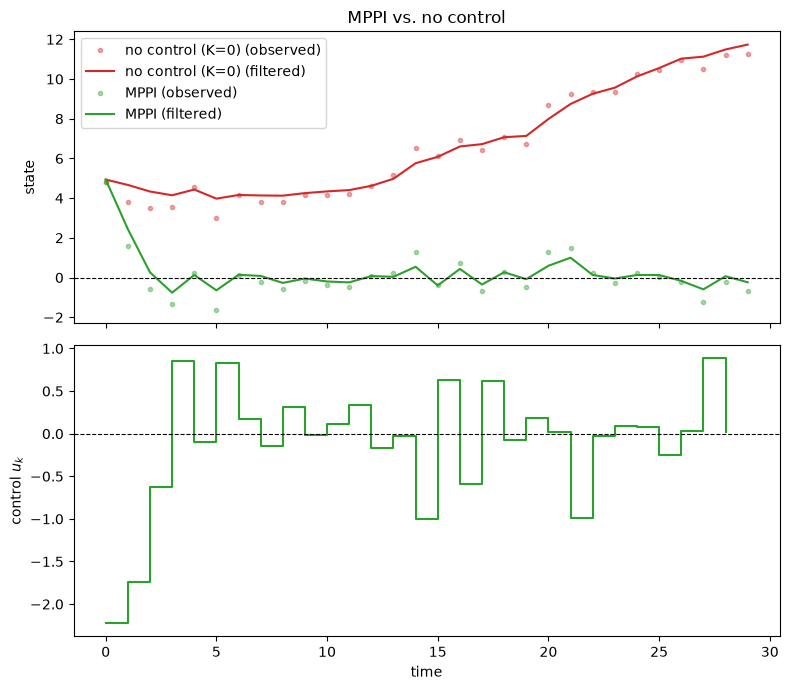

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

runs_mppi = [
    (result_uncontrolled, "no control (K=0)", "tab:red"),
    (result_mppi, "MPPI", "tab:green"),
]
for result, label, color in runs_mppi:
    t = result.times[0]
    obs = result.observations[0, :, 0]
    filtered_mean = result.filtered_states_mean[0, :, 0]
    axes[0].plot(t, obs, ".", color=color, alpha=0.4, label=f"{label} (observed)")
    axes[0].plot(t, filtered_mean, "-", color=color, label=f"{label} (filtered)")

axes[0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("state")
axes[0].legend()
axes[0].set_title("MPPI vs. no control")

t_u = result_mppi.times[0][:-1]
u = result_mppi.controls[0, :, 0]
axes[1].step(t_u, u, where="post", color="tab:green")
axes[1].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("control $u_k$")
axes[1].set_xlabel("time")

plt.tight_layout()
plt.show()